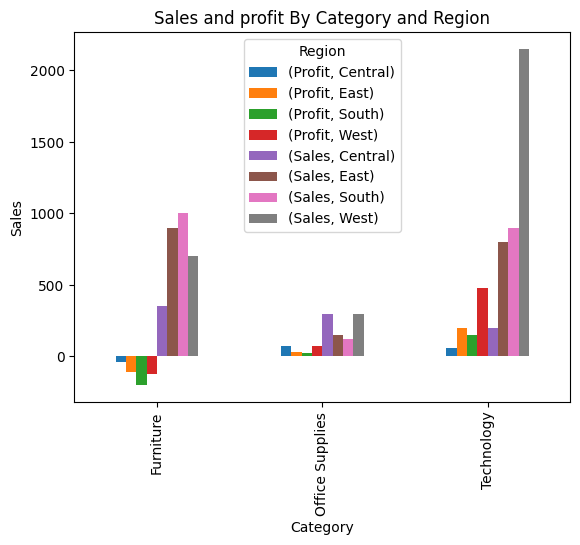

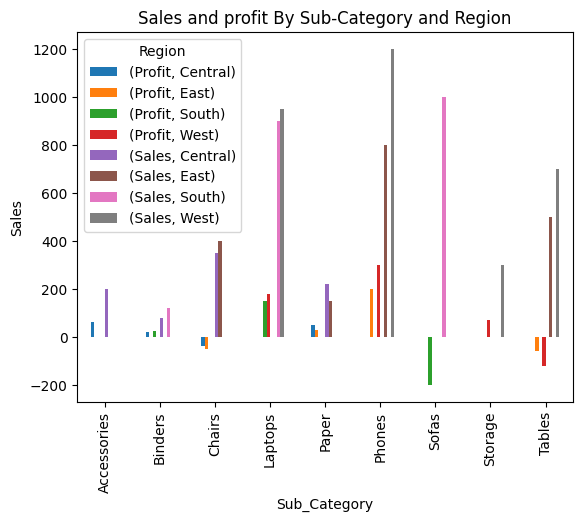

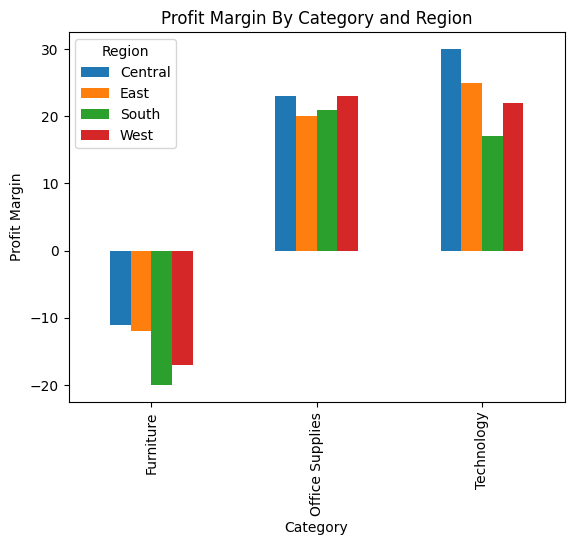

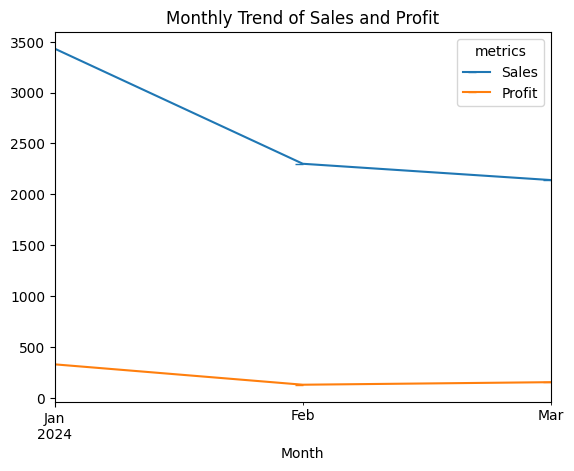

SALES AND PROFIT BY CATEGORY AND REGION
                 Profit                   Sales                 
Region          Central East South West Central East South  West
Category                                                        
Furniture           -40 -110  -200 -120     350  900  1000   700
Office Supplies      70   30    25   70     300  150   120   300
Technology           60  200   150  480     200  800   900  2150

SALES AND PROFIT BY SUB-CATEGORY AND REGION
              Profit                        Sales                       
Region       Central   East  South   West Central   East   South    West
Sub_Category                                                            
Accessories     60.0    0.0    0.0    0.0   200.0    0.0     0.0     0.0
Binders         20.0    0.0   25.0    0.0    80.0    0.0   120.0     0.0
Chairs         -40.0  -50.0    0.0    0.0   350.0  400.0     0.0     0.0
Laptops          0.0    0.0  150.0  180.0     0.0    0.0   900.0   950.0
Paper         

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

filename = r'/content/retail.csv'

df = pd.read_csv(filename)
df['Order_Date']=pd.to_datetime(df['Order_Date'])

total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
AOV = (total_sales/df['Sales'].count())
pm = (total_profit/total_sales)*100

cat_sales_region=df.pivot_table(values=['Sales','Profit'],index='Category',columns='Region',aggfunc='sum')
cat_sales_region.plot(kind='bar')
plt.title('Sales and profit By Category and Region')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.legend(title='Region')
plt.show()

sub_sales_region=df.pivot_table(values=['Sales','Profit'],index='Sub_Category',columns='Region',aggfunc='sum')
sub_sales_region=sub_sales_region.fillna(0)
sub_sales_region.plot(kind='bar')
plt.title('Sales and profit By Sub-Category and Region')
plt.xlabel('Sub_Category')
plt.ylabel('Sales')
plt.legend(title='Region')
plt.show()

Profit_Margin =((cat_sales_region['Profit']/cat_sales_region['Sales'])*100).round()
Profit_Margin.plot(kind='bar')
plt.title('Profit Margin By Category and Region')
plt.xlabel('Category')
plt.ylabel('Profit Margin')
plt.show()

df['Month']=df['Order_Date'].dt.to_period('M')
monthly = df.groupby('Month')[['Sales','Profit']].sum()
monthly.plot(kind='line',marker=0)
plt.title('Monthly Trend of Sales and Profit')
plt.legend(title='metrics')
plt.show()

print('SALES AND PROFIT BY CATEGORY AND REGION')
print(cat_sales_region)
print()
print('SALES AND PROFIT BY SUB-CATEGORY AND REGION')
print(sub_sales_region)
print()
print('PROFIT MARGIN BY CATEGORY AND REGION')
print(Profit_Margin)
print()
print('Total Sales:',total_sales)
print()
print('Total_Profit:',total_profit)
print()
print('Profit Margin:',pm.round())
print()
print('AOV:',AOV.round())
print()
print(monthly)